In [2]:
import pymc

In [8]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import os
import json

In [5]:
os.chdir("..")

In [12]:
STATS_PATH = "data/mileage_stats.json"
with open(STATS_PATH, 'r') as f:
    stats = json.load(f)
mean_mileage = stats['mean_mileage']
std_mileage = stats['std_mileage']

In [11]:
columns_needed = [
    'make', 'model', 'engineSize_bucket', 
    'defect_count_advisory', 'defect_count_dangerous', 
    'mileage_estimate', 'years_estimate', 
    'event_interval'
]
df = pd.read_parquet('data/mot_last_test.parquet', columns=columns_needed).head(10000)

In [23]:
# 3. Preprocessing data
# --- code categorical variables for pymc ---
df['make_id'] = df['make'].astype('category').cat.codes
df['model_id'] = df['model'].astype('category').cat.codes
df['engine_id'] = df['engineSize_bucket'].astype('category').cat.codes

# --- Continuous (Using Fixed Stats) ---
df['mileage_std'] = (df['mileage_estimate'] - mean_mileage) / std_mileage
df['log_time'] = np.log(df['years_estimate'])


In [25]:
make_ids = df['make_id'].values
model_ids = df['model_id'].values
engine_ids = df['engine_id'].values
mileage_std = df['mileage_std'].values
defect_advisory = df['defect_count_advisory'].values
defect_dangerous = df['defect_count_dangerous'].values
log_time = df['log_time'].values
event_interval = df['event_interval'].values

In [31]:
with pm.Model(coords={
    "make_id": np.arange(df['make'].nunique()),
    "model_id": np.arange(df['model'].nunique()),
    "engine_id": np.arange(df['engineSize_bucket'].nunique())
}) as hierarchical_weibull:
    
    # --- Priors ---
    mu_global = pm.Normal('mu_global', mu=0, sigma=5)
    sigma_global = pm.HalfNormal('sigma_global', sigma=1)
    
    # --- Hierarchical Effects ---
    make_effect = pm.Normal('make_effect', mu=0, sigma=1, dims='make_id')
    model_effect = pm.Normal('model_effect', mu=0, sigma=0.5, dims='model_id')
    
    # --- Fixed Effects ---
    engine_effect = pm.Normal('engine_effect', mu=0, sigma=0.5, dims='engine_id')
    
    # Continuous Covariates
    beta_mileage = pm.Normal('beta_mileage', mu=0, sigma=1)
    beta_advisory = pm.Normal('beta_advisory', mu=0, sigma=1)
    beta_dangerous = pm.Normal('beta_dangerous', mu=0, sigma=1)
    
    # --- Linear Predictor ---
    mu = (mu_global + 
          make_effect[make_ids] + 
          model_effect[model_ids] + 
          engine_effect[engine_ids] + 
          beta_mileage * mileage_std +
          beta_advisory * defect_advisory +
          beta_dangerous * defect_dangerous)
    
    # --- Likelihood ---
    log_lik = pm.math.switch(
        event_interval == 1,
        -pm.math.log(sigma_global) - (log_time - mu)/sigma_global - pm.math.exp(-(log_time - mu)/sigma_global),
        -pm.math.exp(-(log_time - mu)/sigma_global)
    )
    
    pm.Potential('weibull_likelihood', log_lik)
    # 5. Sampling
    print("Running NUTS sampler...")
    trace = pm.sample(2000, tune=1000, target_accept=0.9, random_seed=42, return_inferencedata=True)

Running NUTS sampler...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_global, sigma_global, make_effect, model_effect, engine_effect, beta_mileage, beta_advisory, beta_dangerous]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 226 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [35]:
vars_to_check = [
    'mu_global', 'sigma_global', 
    'make_effect', 'model_effect', 'engine_effect',
    'beta_mileage', 'beta_advisory', 'beta_dangerous'
]
print("Available variables in trace:", list(trace.posterior.data_vars))


# 3. Filter to only those that exist in the trace
existing_vars = [v for v in vars_to_check if v in trace.posterior.data_vars]

if existing_vars:
    # Calculate R-hat using the posterior DataArray directly
    rhat = az.rhat(trace.posterior, var_names=existing_vars)
    print(rhat)
else:
    print("None of the requested variables were found in the trace.")

Available variables in trace: ['mu_global', 'make_effect', 'model_effect', 'engine_effect', 'beta_mileage', 'beta_advisory', 'beta_dangerous', 'sigma_global']
<xarray.Dataset> Size: 25kB
Dimensions:         (make_id: 106, model_id: 1421, engine_id: 14)
Coordinates:
  * make_id         (make_id) int64 848B 0 1 2 3 4 5 ... 100 101 102 103 104 105
  * model_id        (model_id) int64 11kB 0 1 2 3 4 ... 1416 1417 1418 1419 1420
  * engine_id       (engine_id) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
Data variables:
    mu_global       float64 8B 1.004
    sigma_global    float64 8B 1.0
    make_effect     (make_id) float64 848B 1.001 1.0 1.005 ... 1.002 1.0 1.0
    model_effect    (model_id) float64 11kB 1.0 1.0 1.0 1.001 ... 1.0 1.0 1.0
    engine_effect   (engine_id) float64 112B 1.002 1.002 1.002 ... 1.001 1.001
    beta_mileage    float64 8B 1.0
    beta_advisory   float64 8B 1.0
    beta_dangerous  float64 8B 1.0
Attributes:
    created_at:                 2026-09-01T21:28:11.896624

In [36]:
vars_to_check = ['mu_global', 'sigma_global', 'make_effect', 'model_effect', 'beta_mileage']

# Use the posterior DataArray directly
rhat = az.rhat(trace.posterior, var_names=vars_to_check)

# Print the results
print(rhat)

<xarray.Dataset> Size: 24kB
Dimensions:       (make_id: 106, model_id: 1421)
Coordinates:
  * make_id       (make_id) int64 848B 0 1 2 3 4 5 6 ... 100 101 102 103 104 105
  * model_id      (model_id) int64 11kB 0 1 2 3 4 5 ... 1416 1417 1418 1419 1420
Data variables:
    mu_global     float64 8B 1.004
    sigma_global  float64 8B 1.0
    make_effect   (make_id) float64 848B 1.001 1.0 1.005 ... 1.002 1.0 1.0
    model_effect  (model_id) float64 11kB 1.0 1.0 1.0 1.001 ... 1.0 1.0 1.0
    beta_mileage  float64 8B 1.0
Attributes:
    created_at:                 2026-09-01T21:28:11.896624+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5
    sampling_time:              226.4594280719757
    tuning_steps:               1000


In [37]:
# Calculate the mean and SD of the posterior
posterior_stats = trace.posterior.mean(dim=['chain', 'draw'])
print("Posterior Means:")
print(posterior_stats[['mu_global', 'sigma_global', 'beta_mileage', 'beta_advisory', 'beta_dangerous']])

# Check the SD for the hierarchical effects
print("\nMake Effect Mean (should vary):")
print(posterior_stats['make_effect'])

Posterior Means:
<xarray.Dataset> Size: 40B
Dimensions:         ()
Data variables:
    mu_global       float64 8B 1.432
    sigma_global    float64 8B 0.3195
    beta_mileage    float64 8B 0.1177
    beta_advisory   float64 8B 0.01075
    beta_dangerous  float64 8B -0.02014
Attributes:
    created_at:                 2026-09-01T21:28:11.896624+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5
    sampling_time:              226.4594280719757
    tuning_steps:               1000

Make Effect Mean (should vary):
<xarray.DataArray 'make_effect' (make_id: 106)> Size: 848B
array([ 0.33097991,  0.41695559,  0.18450546, -0.87608226, -0.75220667,
       -0.4097481 , -0.90116288, -0.91786014, -0.36738352, -0.21975601,
        0.51150248,  0.61368884, -0.35662975, -0.26264247,  0.38058406,
        0.07212935,  0.24499224,  0.28240454,  0.01809285, -1.02420256,
       -0.54282106,  0.77914247,  0.95488838,  1.31470193,  0.6306

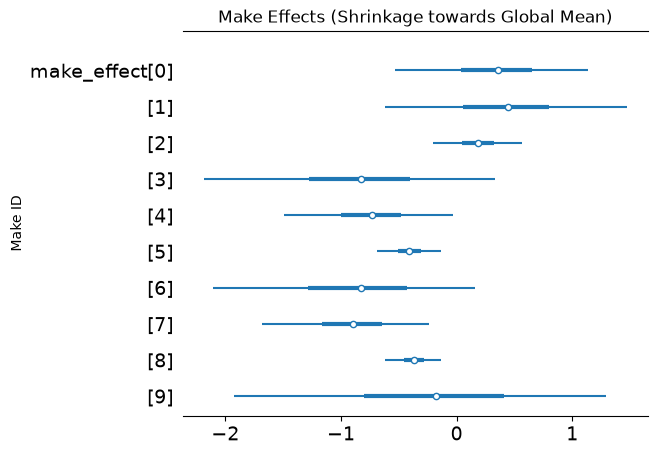

In [44]:
# 1. Plot the Make Effects (Forest Plot)
# This shows how much each Make deviates from the Global Mean
az.plot_forest(trace, var_names=['make_effect'], kind='forestplot', combined=True,
               coords={'make_id': range(10)}) # Show first 10 makes for clarity
plt.title('Make Effects (Shrinkage towards Global Mean)')
plt.ylabel('Make ID')
plt.show()


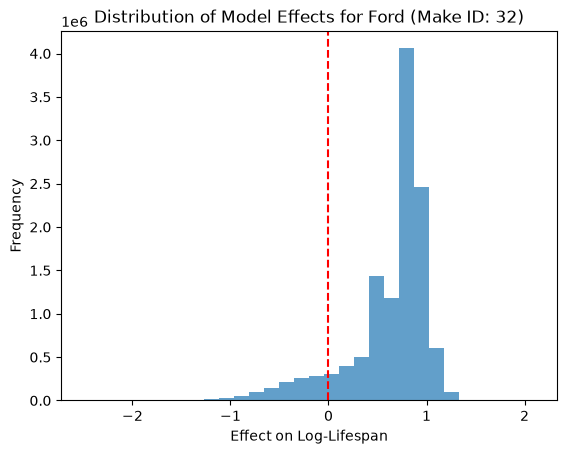

In [47]:

# 2. Plot the Model Effects for a specific Make (e.g., Ford)
# You need to find the Make ID for Ford first
ford_make_id = df[df['make'] == 'FORD']['make_id'].iloc[0]

# Filter the posterior for Ford's models
ford_model_effects = trace.posterior['model_effect'].sel(model_id=df[df['make']=='FORD']['model_id'].values)

# Plot histogram of Ford's models
ford_model_effects.plot.hist(bins=30, alpha=0.7)
plt.title(f'Distribution of Model Effects for Ford (Make ID: {ford_make_id})')
plt.xlabel('Effect on Log-Lifespan')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--') # Show global mean
plt.show()

In [43]:
print(df['make'].unique())

['SKODA' 'VOLKSWAGEN' 'MITSUBISHI' 'MAZDA' 'VAUXHALL' 'TOYOTA' 'FORD'
 'MERCEDES-BENZ' 'NISSAN' 'HONDA' 'LAND ROVER' 'PEUGEOT' 'HARLEY DAVIDSON'
 'BENTLEY' 'BMW' 'LAMBORGHINI' 'PORSCHE' 'KIA' 'MINI' 'FERRARI' 'AUDI'
 'ABARTH' 'LEXUS' 'SMART (MCC)' 'ALFA ROMEO' 'VOLVO' 'ASTON MARTIN'
 'MERCEDES' 'RENAULT' 'JEEP' 'ROLLS ROYCE' 'MCLAREN' 'CITROEN' 'JAGUAR'
 'SEAT' 'TESLA' 'CADILLAC' 'LAMBO' 'FIAT' 'HYUNDAI' 'SUZUKI' 'DACIA'
 'WESTFIELD ELEVEN' 'ROVER' 'SUBARU' 'SAAB' 'MAN' 'DAIMLER' 'ISUZU'
 'IVECO' 'CHEVROLET' 'OPEL' 'MG' 'CARVER CARGO' 'MASERATI' 'SSANGYONG'
 'SMART' 'LOTUS' 'CHRYSLER' 'BUELL' 'DODGE' 'LDV' 'AUTO-SLEEPERS'
 'DAIHATSU' 'CHRYSLER-JEEP' 'HARLEY-DAVIDSON' 'YAMAHA' 'PROTON' 'KAWASAKI'
 'MOTO GUZZI' 'PERODUA' 'TRIUMPH' 'DS' 'PONTIAC' 'GENERAL MOTORS'
 'INFINITI' 'KTM' 'REWACO' 'APRILIA' 'DUCATI' 'CUPRA' 'TALBOT' 'CAN-AM'
 'VOLKSWAGEN GOLF TREND FSI 1.6L' 'DAEWOO' 'DUCATO CARTHAGO 150' 'DFSK'
 'CHEVROLET GMC' 'MERCURY' 'SCION' 'GREAT WALL' 'PIAGGIO' 'RENAULT TRUCKS'
 'MORGAN' 